In [1]:
import numpy as np                # np  → fast maths & arrays
import pandas as pd               # pd  → tables & data manipulation
import matplotlib.pyplot as plt   # plt → basic plotting
import seaborn as sns

In [3]:
data=pd.read_csv('uber-data (8).csv')
data.head()

,Request id,Pickup point,Driver id,Status,Request timestamp,Drop timestamp
0,619,Airport,1.0,Trip Completed,2016-11-07 11:51:00,2016-11-07 13:00:00
1,867,Airport,1.0,Trip Completed,2016-11-07 17:57:00,2016-11-07 18:47:00
2,1807,City,1.0,Trip Completed,2016-12-07 09:17:00,2016-12-07 09:58:00
3,2532,Airport,1.0,Trip Completed,2016-12-07 21:08:00,2016-12-07 22:03:00
4,3112,City,1.0,Trip Completed,2016-07-13 08:33:16,2016-07-13 09:25:47


In [4]:
data.shape

(6745, 6)

In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6745 entries, 0 to 6744
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Request id         6745 non-null   int64         
 1   Pickup point       6745 non-null   str           
 2   Driver id          4095 non-null   float64       
 3   Status             6745 non-null   str           
 4   Request timestamp  6745 non-null   datetime64[us]
 5   Drop timestamp     2831 non-null   datetime64[us]
dtypes: datetime64[us](2), float64(1), int64(1), str(2)
memory usage: 316.3 KB


In [7]:
data['Request timestamp'] = pd.to_datetime(data['Request timestamp'])
data['Drop timestamp']=pd.to_datetime(data['Drop timestamp'])

In [9]:
data['RequestHour']= data['Request timestamp'].dt.hour

In [17]:
data['RequestDayName']=data['Request timestamp'].dt.day_name()

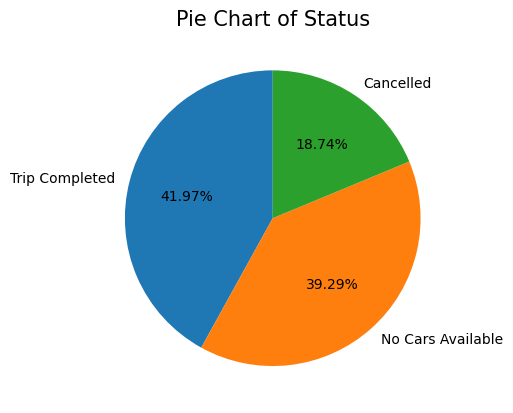

In [123]:
data['Status'].value_counts(normalize=True).plot(kind='pie',label=True,startangle=90,autopct="%1.2f%%",fontsize=10)
plt.title('Pie Chart of Status',fontsize=15)
# plt.show()
plt.savefig('pie_status.png')


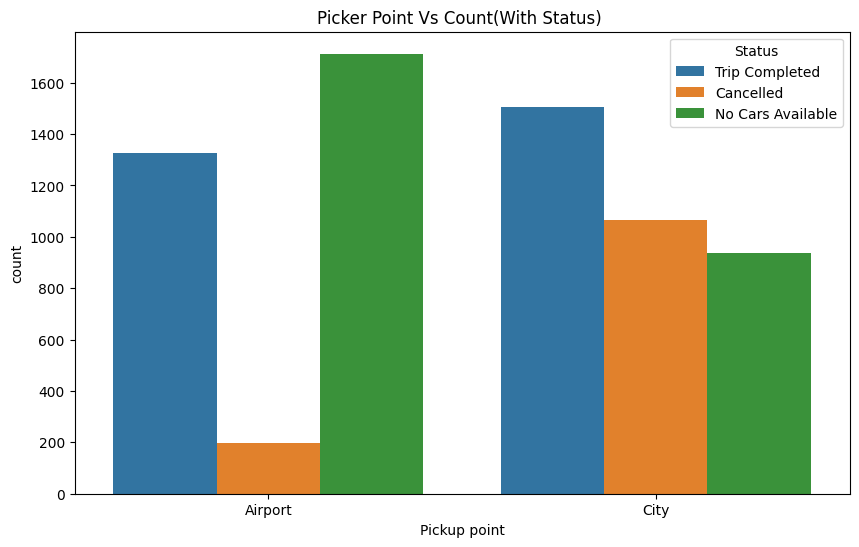

In [125]:
plt.figure(figsize=(10,6))
sns.countplot(x='Pickup point',data=data,hue='Status')
plt.title('Picker Point Vs Count(With Status) ')
# plt.show()
plt.savefig('Picker_Point.png')

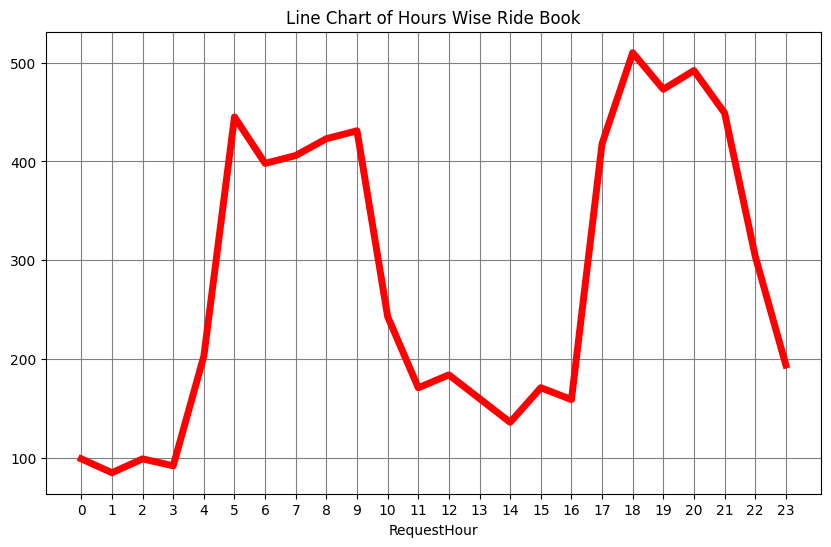

In [126]:
plt.figure(figsize=(10,6))
hr_data=data.groupby('RequestHour').size()
sns.lineplot(x=hr_data.index,y=hr_data.values,linewidth=5,color="red")
plt.xticks(range(0,24))
plt.title('Line Chart of Hours Wise Ride Book')
plt.grid(color='grey')
# plt.show()
plt.savefig('lineChart_hrWise.png')

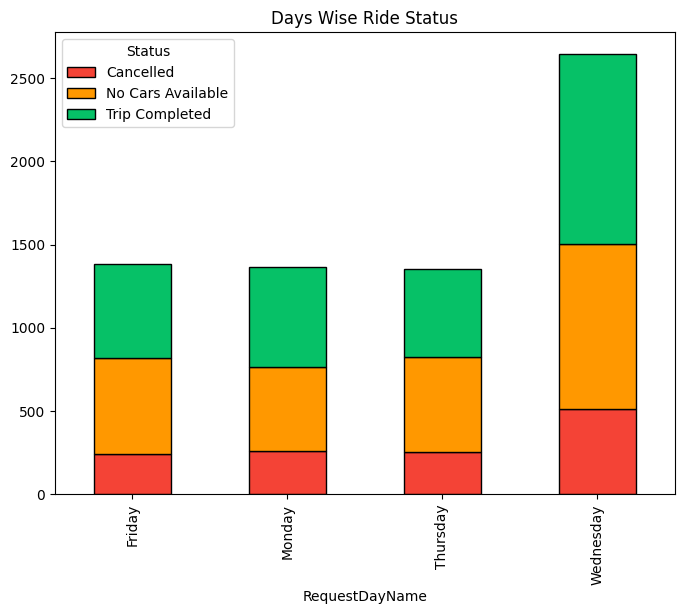

In [127]:
day_status.plot(kind='bar',stacked=True,color=['#F44336', '#FF9800', '#06C167'],edgecolor='black',figsize=(8,6))
plt.title('Days Wise Ride Status')
plt.savefig('Days_Wise.png')

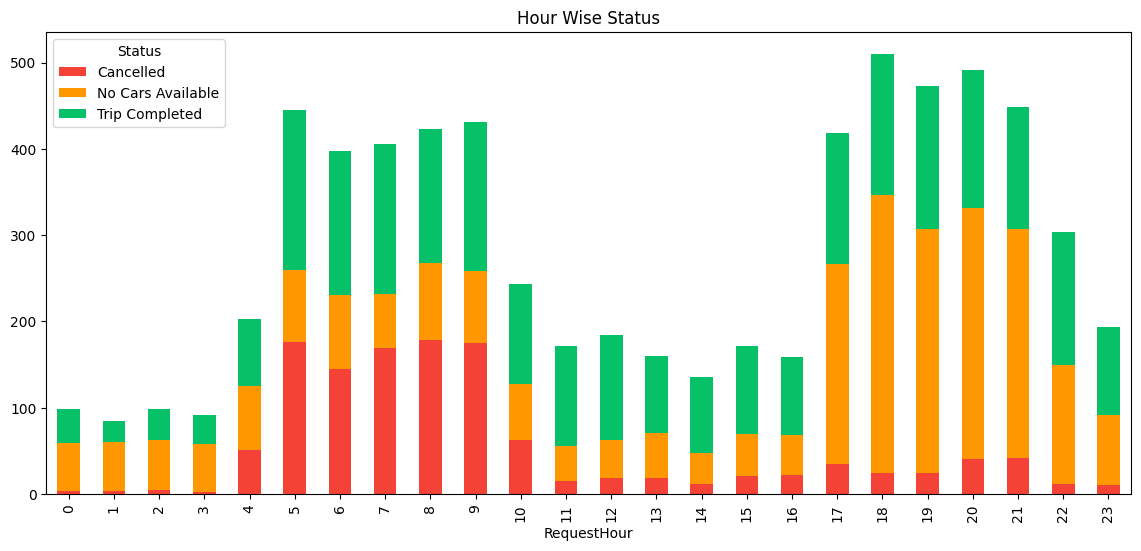

In [128]:
hd_status=data.groupby(['RequestHour','Status']).size().unstack()
hd_status.plot(kind='bar',stacked=True,color=['#F44336', '#FF9800', '#06C167'],figsize=(14,6))
plt.title('Hour Wise Status')
plt.show()
plt.savefig('BarChart_Hour_Wise.png')

In [101]:
city_df=data[data['Pickup point']=='City']

In [104]:
hr_city_status=city_df.groupby(['RequestHour','Status']).size().unstack()

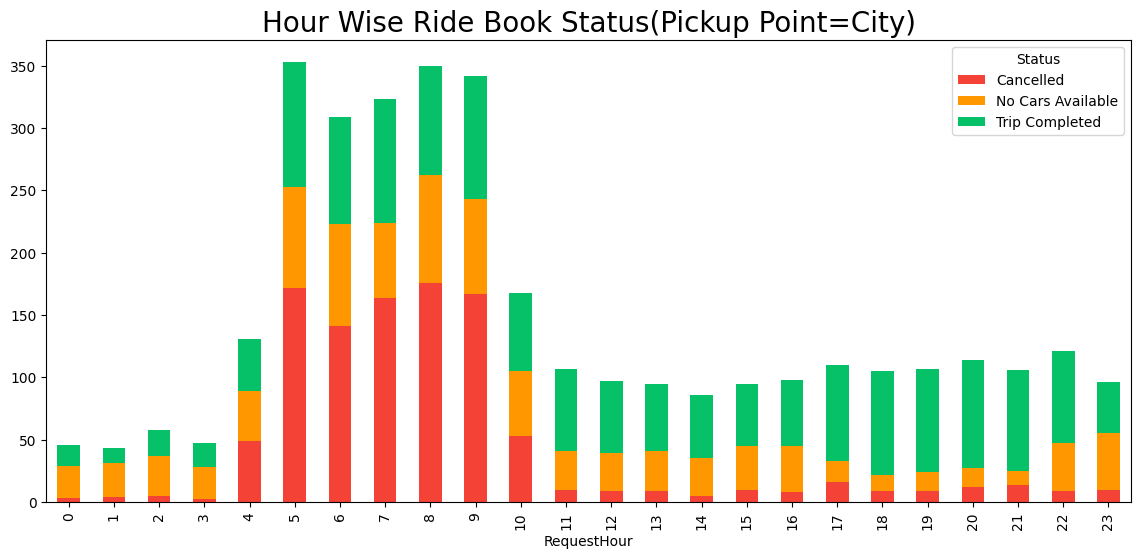

In [129]:
hr_city_status.plot(kind='bar',stacked=True,color=['#F44336', '#FF9800', '#06C167'],figsize=(14,6))
plt.title('Hour Wise Ride Book Status(Pickup Point=City)',fontsize=20)
# plt.show()
plt.savefig('BarChart_Hour_Wise(city).png')


In [116]:
Airpot_df=data[data['Pickup point']=='Airport']
hr_Air_status=Airpot_df.groupby(['RequestHour','Status']).size().unstack()

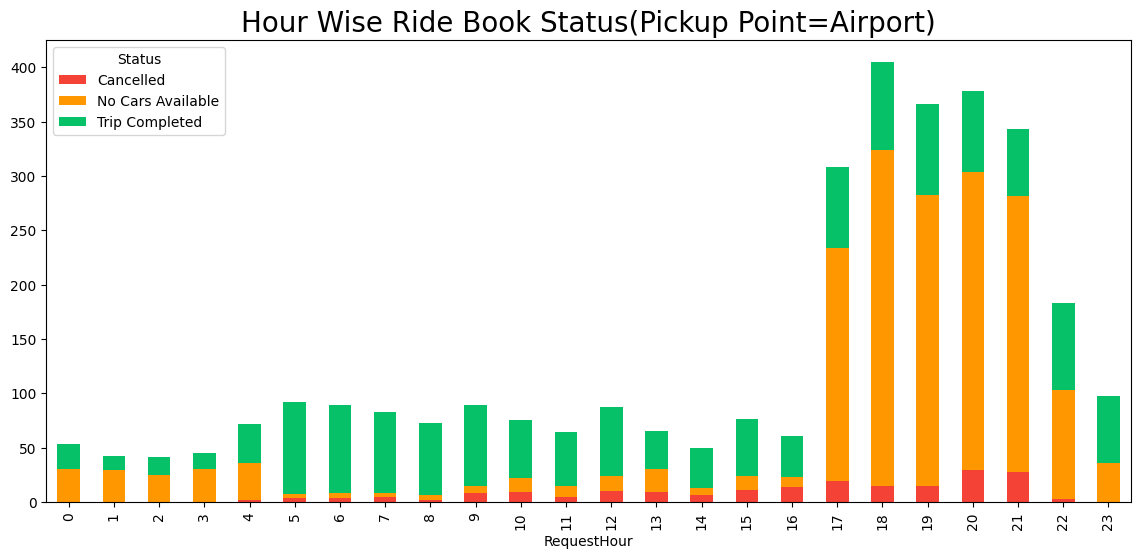

In [130]:
hr_Air_status.plot(kind='bar',stacked=True,color=['#F44336', '#FF9800', '#06C167'],figsize=(14,6))
plt.title('Hour Wise Ride Book Status(Pickup Point=Airport)',fontsize=20)
# plt.show()
plt.savefig('BarChart_Hour_Wise(Airport).png')